<a href="https://colab.research.google.com/github/sebakrys/data-science-bootcamp-A-Z/blob/main/35_s9_rectangle_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
from google.colab.patches import cv2_imshow
import imutils

cv2.__version__

'4.10.0'

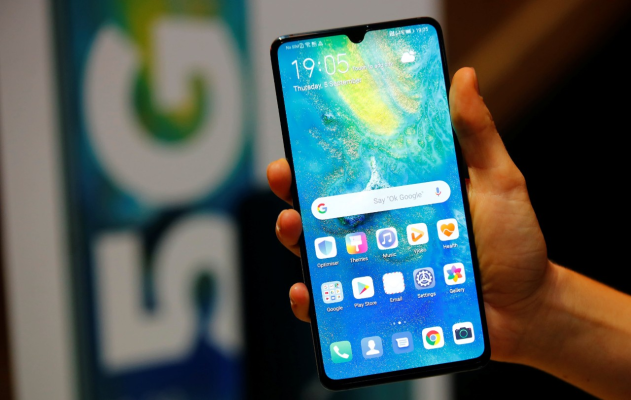

In [3]:
image = cv2.imread('phone.jpg')
image = imutils.resize(image, height=400)
cv2_imshow(image)

#Konwersja do odcieni szarości


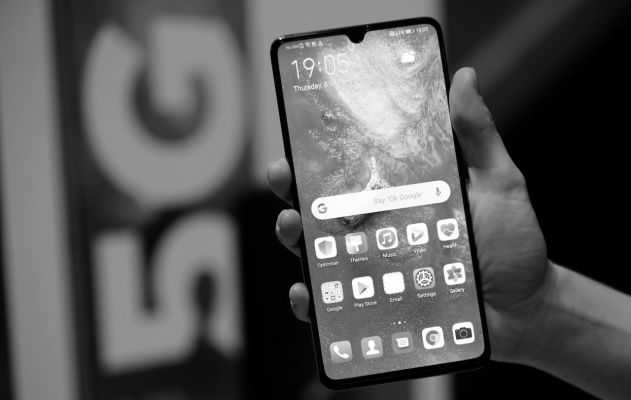

In [4]:
gray_image = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_image)

#Detekcja krawędzi

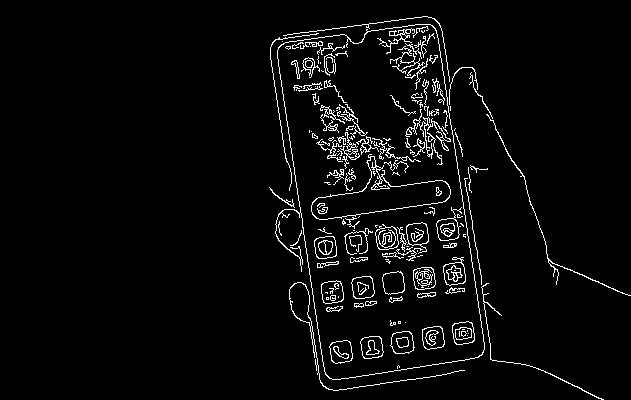

In [5]:
edges1 = cv2.Canny(image=gray_image, threshold1=70, threshold2=200)
cv2_imshow(edges1)

##Rozmycie zdjęcia

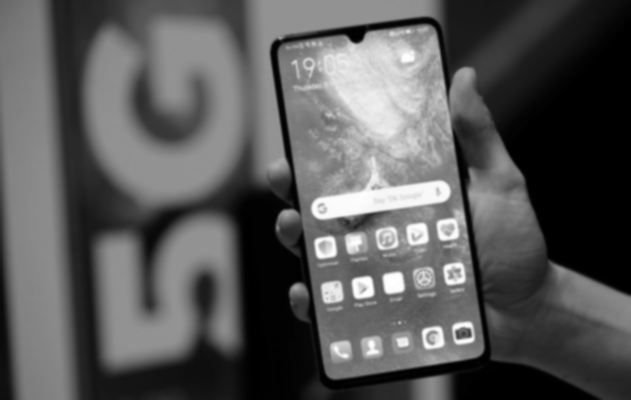

In [6]:
gray_image = cv2.GaussianBlur(src=gray_image, ksize=(5, 5), sigmaX=0)
cv2_imshow(gray_image)

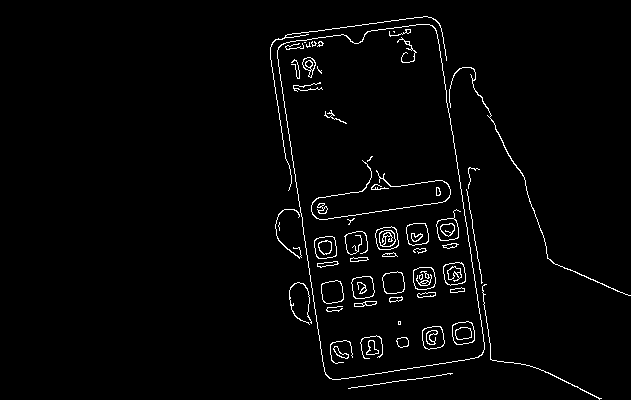

In [7]:
edges = cv2.Canny(image=gray_image, threshold1=70, threshold2=200)
cv2_imshow(edges)

##Detekcja konturu


In [8]:
contours = cv2.findContours(image=edges.copy(),
                            mode=cv2.RETR_TREE,
                            method=cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

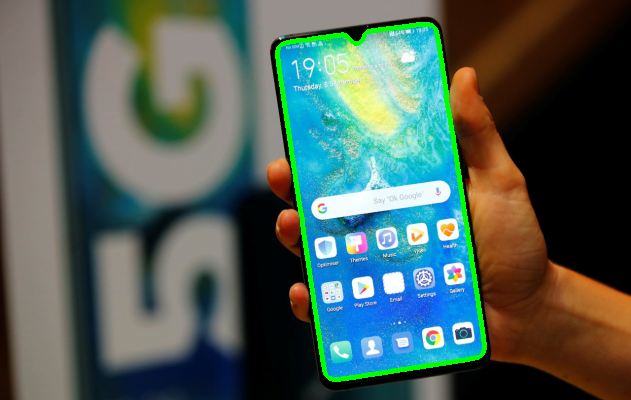

In [9]:
cnt1 = cv2.drawContours(image=image.copy(), contours=[contours[0]], contourIdx=-1,
                        color=(0, 255, 0), thickness=3)
cv2_imshow(cnt1)

0
1
2
3
4
5
6
7
8
9


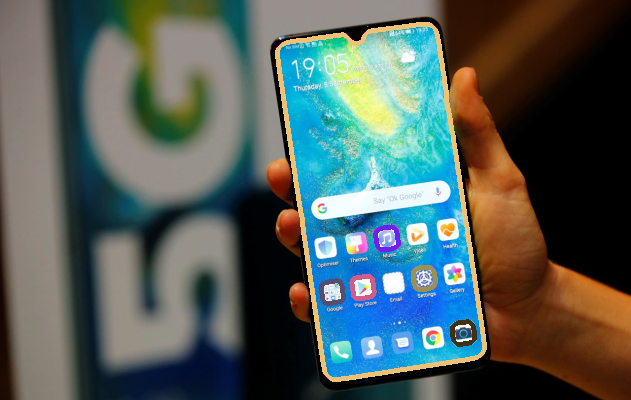

In [24]:
img_copy = image.copy()
for i in range(0, 10):
  print(i)
  color = tuple(int(c) for c in np.random.choice(range(256), size=3))
  img_copy = cv2.drawContours(image=img_copy, contours=[contours[i]], contourIdx=-1,
                              color=color, thickness=3)
cv2_imshow(img_copy)

##Detekcja prostokąta

In [25]:
screen_contour = None

for contour in contours:
    perimeter = cv2.arcLength(curve=contour, closed=True)
    approx = cv2.approxPolyDP(curve=contour, epsilon=0.015 * perimeter, closed=True)

    if len(approx) == 4:
        screen_contour = approx
        break

In [26]:
screen_contour

array([[[429,  24]],

       [[277,  50]],

       [[332, 379]],

       [[484, 349]]], dtype=int32)

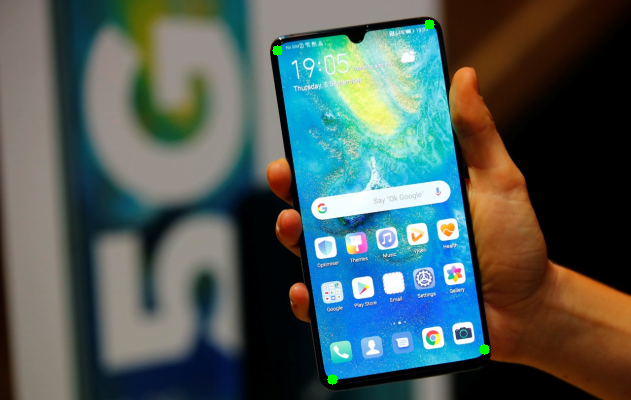

In [27]:
vertices = cv2.drawContours(image=image.copy(), contours=screen_contour, contourIdx=-1, color=(0, 255, 0), thickness=10)
cv2_imshow(vertices)

##Wyświetlenie znalezionego kształtu

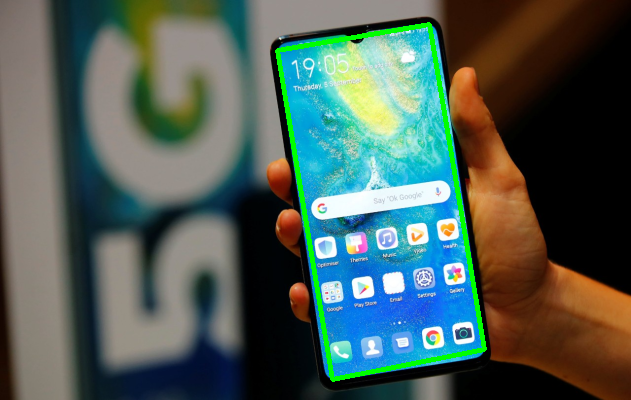

In [28]:
screen_contour = cv2.drawContours(image=image.copy(), contours=[screen_contour], contourIdx=-1, color=(0, 255, 0), thickness=3)
cv2_imshow(screen_contour)